## Payout Plotting

<Axes: xlabel='Date', ylabel='total_profit'>

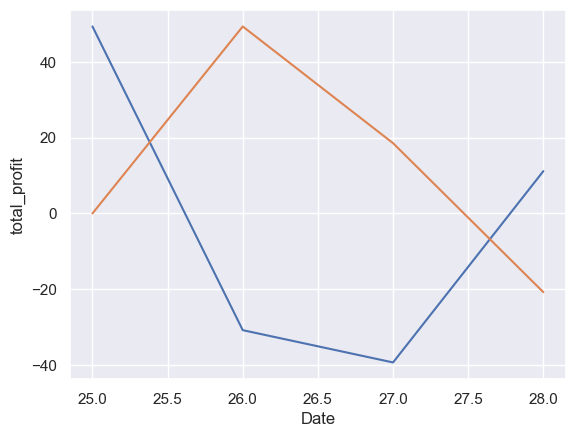

In [7]:
from bet_handle import search_db
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.DataFrame(search_db(False))
df['Payout'] = df['Payout'].astype(float)
df['Wager'] = df['Wager'].astype(float)
df["Date"] = pd.to_datetime(df["Date"])

daily_profit = (
    df.assign(profit=df["Payout"] - df["Wager"])
      .groupby(df["Date"].dt.day)["profit"]
      .sum()
      .reset_index(name="total_profit")
)
daily_profit["net"] = daily_profit["total_profit"].cumsum().shift(1).fillna(0)

sns.set_theme(style="darkgrid")

# Plot the responses for different events and regions
sns.lineplot(x="Date", y="total_profit",
             data=daily_profit)
sns.lineplot(x="Date", y="net",
             data=daily_profit)

In [4]:
df = pd.DataFrame(search_db(False))
df

,ID,Date,Name,Line,Odds,Result,Wager,Payout
0,80,2026-05-28,Ceddanne Rafaela,0.0,+139,None,4.2,None
1,79,2026-05-28,Wilyer Abreu,0.5,-149,None,6.0,None
2,78,2026-05-28,Isiah Kiner-Falefa,0.5,-149,None,6.0,None
3,77,2026-05-28,Willson Contreras,0.5,-200,None,6.7,None
4,76,2026-05-28,Jarren Duran,0.5,-161,None,3.1,None
...,...,...,...,...,...,...,...,...
75,5,2026-05-25,Marcus Semien,0.5,-183,2/4,8.0,12.37
76,4,2026-05-25,Carson Benge,1.5,+280,1/3,4.0,0
77,3,2026-05-25,Carson Benge,0.5,-199,1/3,8.0,12.02
78,2,2026-05-25,Bo Bichette,1.5,+181,3/4,4.0,11.24


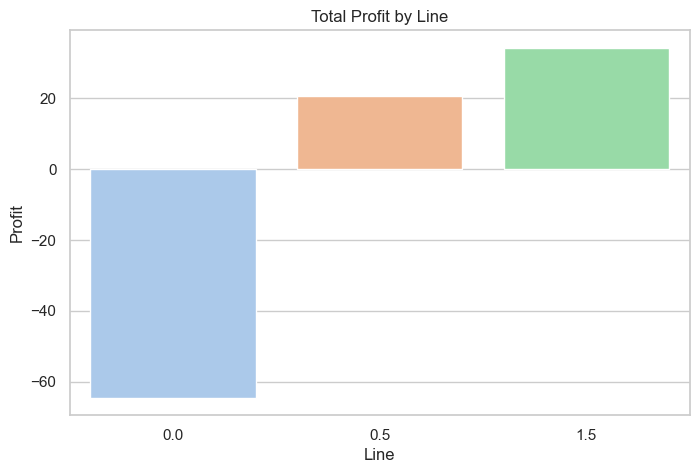

In [ ]:
history_rows = search_db(only_open=False)

if history_rows:
    history_df = pd.DataFrame(history_rows)

    # Make sure numeric columns are usable
    history_df["Line"] = pd.to_numeric(history_df["Line"], errors="coerce")
    history_df["Wager"] = pd.to_numeric(history_df["Wager"], errors="coerce")
    history_df["Payout"] = pd.to_numeric(history_df["Payout"], errors="coerce")

    # Profit = payout - wager
    history_df["Profit"] = history_df["Payout"] - history_df["Wager"]

    # Keep only settled bets and the lines you care about
    chart_df = history_df.dropna(subset=["Line", "Profit"]).copy()
    chart_df = chart_df[chart_df["Line"].isin([0.0, 0.5, 1.5])]
    fig, ax = plt.subplots(figsize=(8, 5))

    sns.barplot(
        data=chart_df,
        x="Line",
        y="Profit",
        estimator=sum,
        errorbar=None,
        ax=ax,
    )

    ax.set_title("Total Profit by Line")
    ax.set_xlabel("Line")
    ax.set_ylabel("Profit")



Text(0, 0.5, 'Average Profit')

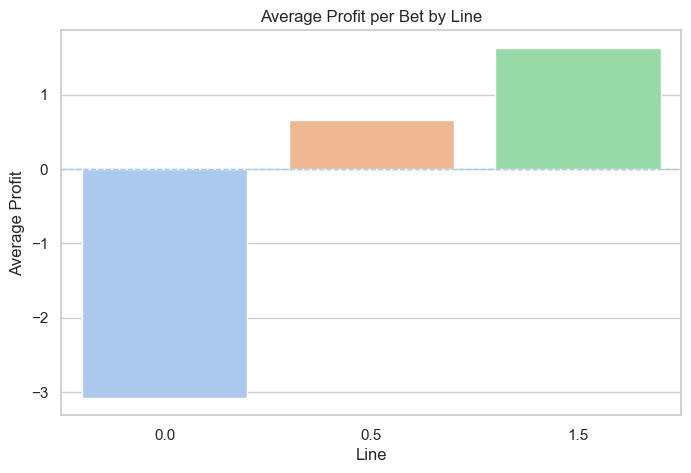

In [12]:
summary_df = (
    chart_df.groupby("Line")
    .agg(
        Average_Profit=("Profit", "mean"),
        Total_Profit=("Profit", "sum"),
        Bets=("Profit", "count"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=summary_df,
    x="Line",
    y="Average_Profit",
    ax=ax,
)

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Average Profit per Bet by Line")
ax.set_xlabel("Line")
ax.set_ylabel("Average Profit")

# for i, row in summary_df.iterrows():
#     ax.text(
#         i,
#         row["Average_Profit"],
#         f"n={int(row['Bets'])}",
#         ha="center",
#         va="bottom" if row["Average_Profit"] >= 0 else "top",
#     )


## Batter and Hitter Data Plots